# 1) pyGIMLi ERT manager

To start, we want to get to know pyGIMLi's capabilities for ERT data, accessible through in `pygimli.physics.ert`.

This package contains **tools, modelling operators, and managers** for Electrical Resistivity Tomography (ERT) & Induced polarization (IP) data, supplying you with tools to **load, visualize, process and invert** your ERT or IP field data.

The main classes are:

* `DataContainer(ERT)` - ERT/IP-specific data container

* `ERTModelling` - Modelling operator

* `ERTManager` - data inversion and modelling for real resistivity

* `ERTIPManager` - extension to IP (either frequency or time domain)

* `TimelapseERT` - processing and inversion of timelapse ERT data

* `CrossholeERT` - timelapse ERT in crosshole environments

This notebook should provide an **overview of the most basic operations** to help you process your own field data. 
To ensure the learning outcomes, we will provide a data set in case you do not have any own data on hand. 

**But we encourage you to process your own data during this workshop!**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg

from pygimli.physics import ert
import pygimli.meshtools as mt

## 1.1 Data import & sensor visualization

In [2]:
data = pg.load("../data/AV_DD_2.dat")

In [3]:
sensors = data.sensorPositions()
sensors[:3]

[[  0.     0.   299.29]
 [  1.     0.   299.2 ]
 [  2.     0.   299.1 ]]

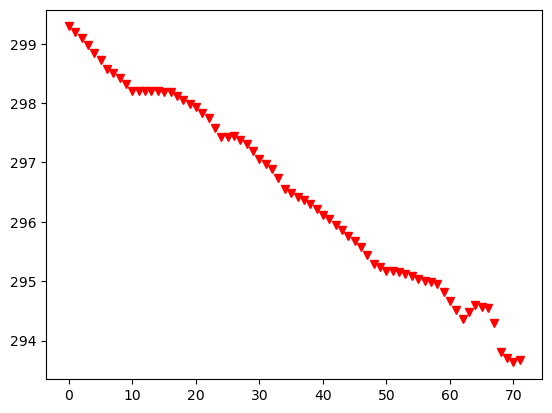

In [4]:
plt.plot(sensors[:,0], sensors[:,2], "rv")
#plt.axis("equal")

## 1.2 Data container structure and data visualization

In [5]:
data.showInfos()

Sensors: 72, Data: 2949
SensorIdx: a b m n  Data: err i ip iperr k r rhoa u valid 


In [6]:
data["k"] = ert.createGeometricFactors(data, numerical=True)
data["rhoa"] = data["k"] * data["r"]

data["err"] = ert.estimateError(data, relativeError=0.02, absoluteError=0.0004)

19/09/26 - 13:11:26 - pyGIMLi - INFO - Cache /Users/fwagner/git/gimli_dev/source/pygimli/physics/ert/ert.py:createGeometricFactors restored (2.1s x 3): /Users/fwagner/Library/Caches/pygimli/14684181247903543916


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x10fb278c0>)

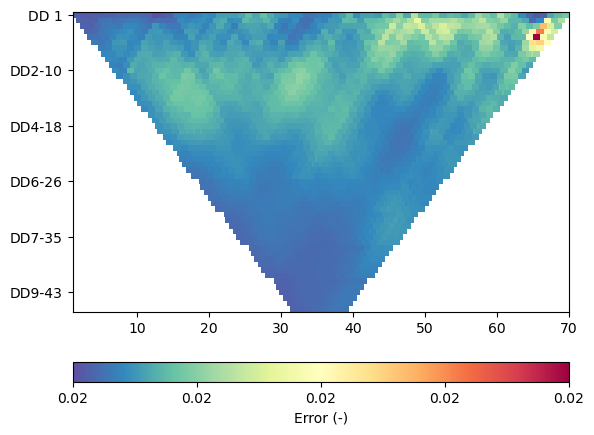

In [7]:
data.show("err")

## 1.3 Data filtering

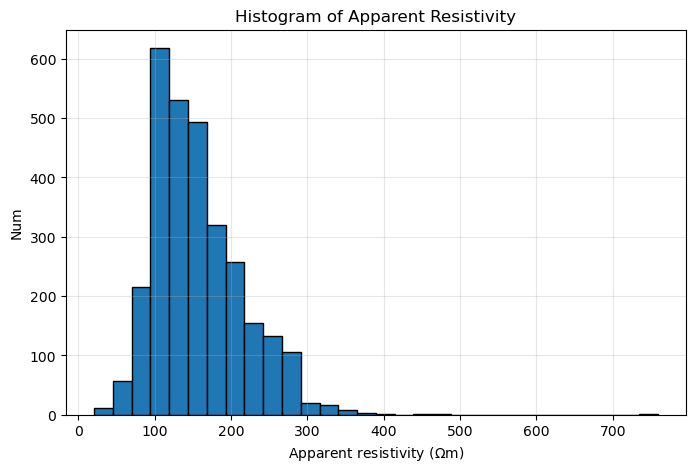

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(data["rhoa"], bins=30, edgecolor="black")
plt.xlabel(r"Apparent resistivity ($\Omega \text{m}$)")
plt.ylabel("Num")
plt.title("Histogram of Apparent Resistivity")
plt.grid(alpha=0.3)
plt.show()

(<Axes: >, <matplotlib.colorbar.Colorbar at 0x10fb529f0>)

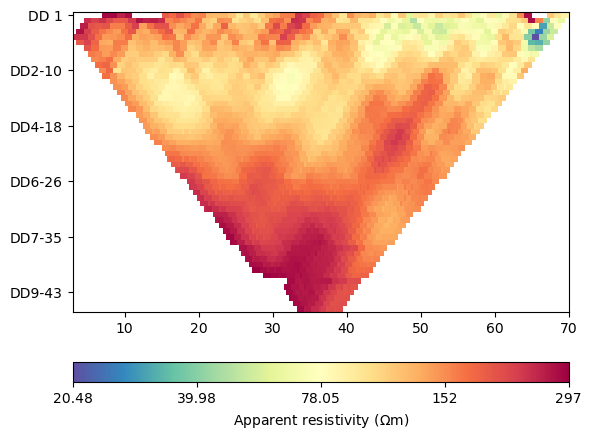

In [9]:
data.remove(data["rhoa"] > 300)
data.show()

In [10]:
#data.removeSensorIdx((67,68))
#data.show()

## 1.4 First inversion

19/09/26 - 13:11:27 - pyGIMLi - INFO - Found 2 regions.
19/09/26 - 13:11:27 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
19/09/26 - 13:11:27 - pyGIMLi - INFO - Found 2 regions.
19/09/26 - 13:11:27 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
19/09/26 - 13:11:27 - pyGIMLi - INFO - Creating forward mesh from region infos.
19/09/26 - 13:11:27 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
19/09/26 - 13:11:27 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3184 Cells: 5996 Boundaries: 4682
19/09/26 - 13:11:27 - pyGIMLi - INFO - Use median(data values)=144.31497826767682


(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x1293c9220>)

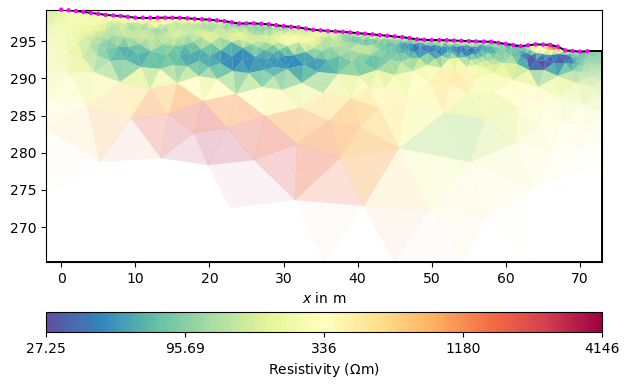

In [11]:
mgr = ert.ERTManager(data)
mgr.invert()
mgr.showResult()

## 1.5 Inversion on customized mesh

Mesh: Nodes: 2124 Cells: 3993 Boundaries: 6116


(<Axes: xlabel='$x$ in m'>, None)

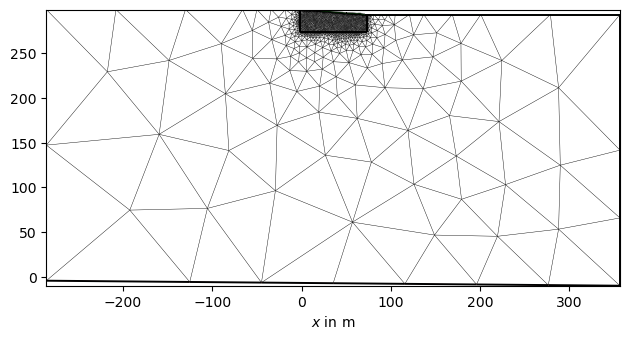

In [12]:
mesh = mt.createParaMesh(data.sensorPositions(), paraDX=0.33, paraDepth=20, paraMaxCellSize=1.25)
print(mesh)
pg.show(mesh)

#mesh.save("../data/mesh_ERT.bms")

In [ ]:
inv = mgr.invert(mesh=mesh, lam=45, verbose=True)

19/09/26 - 13:11:43 - pyGIMLi - INFO - Found 2 regions.
19/09/26 - 13:11:43 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
19/09/26 - 13:11:43 - pyGIMLi - INFO - Creating forward mesh from region infos.
19/09/26 - 13:11:43 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
19/09/26 - 13:11:44 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8240 Cells: 15972 Boundaries: 12232
19/09/26 - 13:11:44 - pyGIMLi - INFO - Use median(data values)=144.31497826767682
19/09/26 - 13:11:44 - pyGIMLi - INFO - Created startmodel from forward operator:3202, min/max=144.314978/144.314978
19/09/26 - 13:11:44 - pyGIMLi - INFO - Starting inversion.
19/09/26 - 13:11:44 - pyGIMLi - INFO - fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x10fb026b0>
19/09/26 - 13:11:44 - pyGIMLi - INFO - Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
19/09/26 - 13:11:44 - pyGIMLi - INFO - Model transformation: Logarithmic trans

In [ ]:
mgr.showResult()

In [ ]:
mgr.showFit()

In [ ]:
mgr.showMisfit()

## 1.6 Save your data and mesh

In [ ]:
#mgr.saveResult()